
# Importing some necessary libraries

In [226]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Data Collection and Pre-Processing

In [227]:
#Loading the datasets
test_data = pd.read_csv(r'C:\Users\vedan\Downloads\test_data.csv')
train_labels = pd.read_csv(r"C:\Users\vedan\Downloads\training_data_targets.csv", header=None).iloc[:, 0].rename('Price')
train_data= pd.read_csv(r'C:\Users\vedan\Downloads\training_data.csv')

In [228]:
#Inspecting the first 5 rows of the dataframes
test_data.head()

,Brand,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Swift Dzire VDI,Hyderabad,2013,69000,Diesel,Manual,First,23.4 kmpl,1248 CC,74 bhp,5.0
1,Mahindra Scorpio 1.99 S4 Plus,Kochi,2017,26741,Diesel,Manual,First,15.4 kmpl,1997 CC,120 bhp,7.0
2,Mahindra XUV500 W8 2WD,Delhi,2014,86000,Diesel,Manual,First,15.1 kmpl,2179 CC,140 bhp,7.0
3,Tata Indigo CS eVX,Pune,2016,52000,Diesel,Manual,Second,25.0 kmpl,1396 CC,69.01 bhp,5.0
4,Hyundai Santro GLS II - Euro II,Pune,2009,100000,Petrol,Manual,First,0.0 kmpl,NaN,NaN,NaN


In [229]:
#Inspecting the first 5 rows of the dataframes
test_data.head()

,Brand,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Swift Dzire VDI,Hyderabad,2013,69000,Diesel,Manual,First,23.4 kmpl,1248 CC,74 bhp,5.0
1,Mahindra Scorpio 1.99 S4 Plus,Kochi,2017,26741,Diesel,Manual,First,15.4 kmpl,1997 CC,120 bhp,7.0
2,Mahindra XUV500 W8 2WD,Delhi,2014,86000,Diesel,Manual,First,15.1 kmpl,2179 CC,140 bhp,7.0
3,Tata Indigo CS eVX,Pune,2016,52000,Diesel,Manual,Second,25.0 kmpl,1396 CC,69.01 bhp,5.0
4,Hyundai Santro GLS II - Euro II,Pune,2009,100000,Petrol,Manual,First,0.0 kmpl,NaN,NaN,NaN


In [230]:
#Checking numberof rows and columns in the dataframes
test_data.shape

(602, 11)

In [231]:
train_data.shape

(5417, 11)

In [232]:
test_data.columns

Index(['Brand', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats'],
      dtype='object')

In [233]:
train_data.columns

Index(['Brand', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats'],
      dtype='object')

In [234]:
train_labels.head()

0     3.20
1    21.50
2     4.75
3     2.90
4     3.87
Name: Price, dtype: float64

# Getting some information about the dataset

In [235]:
#getting some information about the dataset
test_data.describe()

,Year,Kilometers_Driven,Seats
count,602.000000,602.000000,598.000000
mean,2013.308970,57942.551495,5.264214
std,3.143948,43329.671873,0.785392
min,2003.000000,1000.000000,2.000000
25%,2011.000000,32391.500000,5.000000
50%,2014.000000,52308.500000,5.000000
75%,2016.000000,75000.000000,5.000000
max,2019.000000,720000.000000,10.000000


In [236]:
train_data.describe()

,Year,Kilometers_Driven,Seats
count,5417.000000,5.417000e+03,5379.000000
mean,2013.363670,5.882682e+04,5.280350
std,3.283659,9.511826e+04,0.811459
min,1998.000000,1.710000e+02,0.000000
25%,2011.000000,3.400000e+04,5.000000
50%,2014.000000,5.329300e+04,5.000000
75%,2016.000000,7.300000e+04,5.000000
max,2019.000000,6.500000e+06,10.000000


In [237]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              602 non-null    object 
 1   Location           602 non-null    object 
 2   Year               602 non-null    int64  
 3   Kilometers_Driven  602 non-null    int64  
 4   Fuel_Type          602 non-null    object 
 5   Transmission       602 non-null    object 
 6   Owner_Type         602 non-null    object 
 7   Mileage            601 non-null    object 
 8   Engine             600 non-null    object 
 9   Power              600 non-null    object 
 10  Seats              598 non-null    float64
dtypes: float64(1), int64(2), object(8)
memory usage: 51.9+ KB


In [238]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5417 entries, 0 to 5416
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              5417 non-null   object 
 1   Location           5417 non-null   object 
 2   Year               5417 non-null   int64  
 3   Kilometers_Driven  5417 non-null   int64  
 4   Fuel_Type          5417 non-null   object 
 5   Transmission       5417 non-null   object 
 6   Owner_Type         5417 non-null   object 
 7   Mileage            5416 non-null   object 
 8   Engine             5383 non-null   object 
 9   Power              5383 non-null   object 
 10  Seats              5379 non-null   float64
dtypes: float64(1), int64(2), object(8)
memory usage: 465.7+ KB


# Checking the missing values

In [239]:
train_data.isnull().sum()

Brand                 0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               1
Engine               34
Power                34
Seats                38
dtype: int64

In [240]:
test_data.isnull().sum()

Brand                0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              1
Engine               2
Power                2
Seats                4
dtype: int64

# Imputing the missing values

In [241]:
# Impute missing values with the mean
median_seats = train_data['Seats'].median()
train_data['Seats'].fillna(median_seats, inplace=True)

C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\3571010118.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Seats'].fillna(median_seats, inplace=True)


In [242]:
# Assuming 'Mileage' is the column with missing values and it's given in kmpl
mean_mileage = train_data['Mileage'].str.extract('(\d+\.\d+)').astype(float).mean()

# Impute missing values with the mean
train_data['Mileage'].fillna(f'{mean_mileage} kmpl', inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\758636664.py:2: SyntaxWarning: invalid escape sequence '\d'
  mean_mileage = train_data['Mileage'].str.extract('(\d+\.\d+)').astype(float).mean()


In [243]:
# Assuming 'Engine' is the column with missing values and it's given in CC
mean_engine = train_data['Engine'].str.extract('(\d+\.\d+)').astype(float).mean()

# Impute missing values with the mean
train_data['Engine'].fillna(f'{mean_engine} cc', inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\1381764030.py:2: SyntaxWarning: invalid escape sequence '\d'
  mean_engine = train_data['Engine'].str.extract('(\d+\.\d+)').astype(float).mean()


In [244]:
# Assuming 'Power' is the column with missing values and it's given in bhp
mean_power = train_data['Mileage'].str.extract('(\d+\.\d+)').astype(float).mean()

# Impute missing values with the mean
train_data['Power'].fillna(f'{mean_power} bhp', inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\181514849.py:2: SyntaxWarning: invalid escape sequence '\d'
  mean_power = train_data['Mileage'].str.extract('(\d+\.\d+)').astype(float).mean()
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\181514849.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Power'].fillna(f'{mean_power} bhp', inplace=True)


In [245]:
train_data.isnull().sum()

Brand                0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
dtype: int64

In [246]:
#Imputing the missing values with the median
median_seats = test_data['Seats'].median()
test_data['Seats'].fillna(median_seats, inplace=True)

C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\308267463.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Seats'].fillna(median_seats, inplace=True)


In [247]:
# Assuming 'Mileage' is the column with missing values and it's given in kmpl
mean_mileage = test_data['Mileage'].str.extract('(\d+\.\d+)').astype(float).mean()

# Impute missing values with the mean
test_data['Mileage'].fillna(f'{mean_mileage} kmpl', inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\568207240.py:2: SyntaxWarning: invalid escape sequence '\d'
  mean_mileage = test_data['Mileage'].str.extract('(\d+\.\d+)').astype(float).mean()


In [248]:
# Assuming 'Engine' is the column with missing values and it's given in CC
mean_engine = test_data['Engine'].str.extract('(\d+\.\d+)').astype(float).mean()
# Impute missing values with the mean
test_data['Engine'].fillna(f'{mean_engine} cc', inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\3940265422.py:2: SyntaxWarning: invalid escape sequence '\d'
  mean_engine = test_data['Engine'].str.extract('(\d+\.\d+)').astype(float).mean()


In [249]:
# Assuming 'Power' is the column with missing values and it's given in bhp
mean_power = test_data['Power'].str.extract('(\d+\.\d+)').astype(float).mean()

# Impute missing values with the mean
test_data['Power'].fillna(f'{mean_power} bhp', inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\493478375.py:2: SyntaxWarning: invalid escape sequence '\d'
  mean_power = test_data['Power'].str.extract('(\d+\.\d+)').astype(float).mean()


In [250]:
test_data.isnull().sum()

Brand                0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
dtype: int64

# Checking the categorical data

In [251]:
print(train_data.Location.value_counts())
print(train_data.Fuel_Type.value_counts())
print(train_data.Transmission.value_counts())
print(train_data.Owner_Type.value_counts())

Location
Mumbai        706
Hyderabad     668
Coimbatore    579
Kochi         575
Pune          564
Delhi         512
Kolkata       475
Chennai       439
Jaipur        368
Bangalore     333
Ahmedabad     198
Name: count, dtype: int64
Fuel_Type
Diesel      2876
Petrol      2482
CNG           49
LPG            9
Electric       1
Name: count, dtype: int64
Transmission
Manual       3890
Automatic    1527
Name: count, dtype: int64
Owner_Type
First             4431
Second             875
Third              103
Fourth & Above       8
Name: count, dtype: int64


In [252]:
print(test_data.Location.value_counts())
print(test_data.Fuel_Type.value_counts())
print(test_data.Transmission.value_counts())
print(test_data.Owner_Type.value_counts())

Location
Mumbai        84
Kochi         76
Hyderabad     74
Kolkata       60
Pune          58
Coimbatore    57
Chennai       55
Jaipur        45
Delhi         42
Ahmedabad     26
Bangalore     25
Name: count, dtype: int64
Fuel_Type
Diesel      329
Petrol      264
CNG           7
LPG           1
Electric      1
Name: count, dtype: int64
Transmission
Manual       409
Automatic    193
Name: count, dtype: int64
Owner_Type
First             498
Second             93
Third              10
Fourth & Above      1
Name: count, dtype: int64


In [253]:
#Label Encoding "FUEL_TYPE" Column
#train_data.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}}, inplace= True)

#Label Encoding "TRANSMISSION" Column
#train_data.replace({'Transmission':{'Manual':0,'Automatic':1,}}, inplace= True)

#Label Encoding "OWNER_TYPE" Column
#train_data.replace({'Owner_Type':{'First':0,'Second':1,'Third':2,'Fourth & Above':3}}, inplace= True)

#Label Encoding "LOCATION" Column
#train_data.replace({'Location':{'Mumbai':0,'Hyderabad':1,'Coimbatore':2,'Kochi':3,'Pune':4,'Delhi':5,'Kolkata':6,'Chennai':7,'Jaipur':8,'Bangalore':9,'Ahmedabad':10}}, inplace= True)

In [254]:
train_data.head()

,Brand,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Celerio VXI AMT,Delhi,2014,35214,Petrol,Automatic,Second,23.1 kmpl,998 CC,67.04 bhp,5.0
1,Audi Q5 2.0 TDI,Delhi,2013,71000,Diesel,Automatic,First,14.16 kmpl,1968 CC,174.3 bhp,5.0
2,Toyota Etios VXD,Pune,2012,111000,Diesel,Manual,First,23.59 kmpl,1364 CC,67.1 bhp,5.0
3,Maruti Wagon R LXI CNG,Pune,2012,90400,CNG,Manual,First,26.2 km/kg,998 CC,58.2 bhp,5.0
4,Maruti Wagon R AMT VXI,Jaipur,2016,68630,Petrol,Automatic,First,20.51 kmpl,998 CC,67 bhp,5.0


In [255]:
#Label Encoding "FUEL_TYPE" Column
#test_data.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}}, inplace= True)

#Label Encoding "TRANSMISSION" Column
#test_data.replace({'Transmission':{'Manual':0,'Automatic':1,}}, inplace= True)

#Label Encoding "OWNER_TYPE" Column
#test_data.replace({'Owner_Type':{'First':0,'Second':1,'Third':2,'Fourth & Above':3}}, inplace= True)

#Label Encoding "LOCATION" Column
#test_data.replace({'Location':{'Mumbai':0,'Hyderabad':1,'Coimbatore':2,'Kochi':3,'Pune':4,'Delhi':5,'Kolkata':6,'Chennai':7,'Jaipur':8,'Bangalore':9,'Ahmedabad':10}}, inplace= True)

In [256]:
test_data.head()

,Brand,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Swift Dzire VDI,Hyderabad,2013,69000,Diesel,Manual,First,23.4 kmpl,1248 CC,74 bhp,5.0
1,Mahindra Scorpio 1.99 S4 Plus,Kochi,2017,26741,Diesel,Manual,First,15.4 kmpl,1997 CC,120 bhp,7.0
2,Mahindra XUV500 W8 2WD,Delhi,2014,86000,Diesel,Manual,First,15.1 kmpl,2179 CC,140 bhp,7.0
3,Tata Indigo CS eVX,Pune,2016,52000,Diesel,Manual,Second,25.0 kmpl,1396 CC,69.01 bhp,5.0
4,Hyundai Santro GLS II - Euro II,Pune,2009,100000,Petrol,Manual,First,0.0 kmpl,0 NaN\ndtype: float64 cc,0 108.355665\ndtype: float64 bhp,5.0


# Encoding of the dataset

In [257]:
#from sklearn.preprocessing import LabelEncoder

#label_encoder = LabelEncoder()

# Fit and transform 'Brand' column to numerical labels for "Testing dataset"
#test_data['Brand_Label'] = label_encoder.fit_transform(test_data['Brand'])

#print(test_data)

In [258]:
# Fit and transform 'Brand' column to numerical labels for "Training Dataset"
#train_data['Brand_Label'] = label_encoder.fit_transform(train_data['Brand'])

#print(train_data)

# One Hot Encoding

In [259]:
for df in [train_data, test_data]:
    df['Manufacturer'] = df['Brand'].str.split(' ').str[0]
    df['Car_Model'] = df['Brand'].str.split(' ').str[1:].apply(lambda x: ' '.join(x) if x else 'N/A')
    df.drop(columns=['Brand', 'Car_Model'], inplace=True)
    df.rename(columns={'Manufacturer': 'Brand'}, inplace=True)

In [260]:
train_data

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand
0,Delhi,2014,35214,Petrol,Automatic,Second,23.1 kmpl,998 CC,67.04 bhp,5.0,Maruti
1,Delhi,2013,71000,Diesel,Automatic,First,14.16 kmpl,1968 CC,174.3 bhp,5.0,Audi
2,Pune,2012,111000,Diesel,Manual,First,23.59 kmpl,1364 CC,67.1 bhp,5.0,Toyota
3,Pune,2012,90400,CNG,Manual,First,26.2 km/kg,998 CC,58.2 bhp,5.0,Maruti
4,Jaipur,2016,68630,Petrol,Automatic,First,20.51 kmpl,998 CC,67 bhp,5.0,Maruti
...,...,...,...,...,...,...,...,...,...,...,...
5412,Chennai,2015,27000,Petrol,Automatic,First,17.97 kmpl,1498 CC,99.6 bhp,5.0,Nissan
5413,Chennai,2019,9000,Diesel,Automatic,First,12.62 kmpl,2198 CC,158 bhp,7.0,Ford
5414,Hyderabad,2013,140000,Diesel,Manual,Second,15.1 kmpl,2179 CC,140 bhp,7.0,Mahindra
5415,Jaipur,2014,76414,Diesel,Manual,First,25.8 kmpl,1498 CC,98.6 bhp,5.0,Honda


In [261]:
brand_avg_price = train_data.assign(Price=train_labels).groupby('Brand')['Price'].mean()
overall_avg_price = train_labels.mean()

train_data['Brand_Price_Avg'] = train_data['Brand'].map(brand_avg_price)
test_data['Brand_Price_Avg'] = test_data['Brand'].map(brand_avg_price).fillna(overall_avg_price)

In [262]:
train_data

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Brand_Price_Avg
0,Delhi,2014,35214,Petrol,Automatic,Second,23.1 kmpl,998 CC,67.04 bhp,5.0,Maruti,4.523382
1,Delhi,2013,71000,Diesel,Automatic,First,14.16 kmpl,1968 CC,174.3 bhp,5.0,Audi,26.190240
2,Pune,2012,111000,Diesel,Manual,First,23.59 kmpl,1364 CC,67.1 bhp,5.0,Toyota,11.532730
3,Pune,2012,90400,CNG,Manual,First,26.2 km/kg,998 CC,58.2 bhp,5.0,Maruti,4.523382
4,Jaipur,2016,68630,Petrol,Automatic,First,20.51 kmpl,998 CC,67 bhp,5.0,Maruti,4.523382
...,...,...,...,...,...,...,...,...,...,...,...,...
5412,Chennai,2015,27000,Petrol,Automatic,First,17.97 kmpl,1498 CC,99.6 bhp,5.0,Nissan,4.821059
5413,Chennai,2019,9000,Diesel,Automatic,First,12.62 kmpl,2198 CC,158 bhp,7.0,Ford,6.843792
5414,Hyderabad,2013,140000,Diesel,Manual,Second,15.1 kmpl,2179 CC,140 bhp,7.0,Mahindra,8.003264
5415,Jaipur,2014,76414,Diesel,Manual,First,25.8 kmpl,1498 CC,98.6 bhp,5.0,Honda,5.415325


In [173]:
CATEGORICAL_COLS = ['Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']

X_train = train_data.copy()
X_test = test_data.copy()

combined_features = pd.concat([X_train, X_test], keys=['train', 'test'])

combined_encoded = pd.get_dummies(combined_features, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS, drop_first=True)

X_train_final = combined_encoded.loc['train']
X_test_final = combined_encoded.loc['test']

columns_to_drop = ['Location']
X_train_final = X_train_final.drop(columns=columns_to_drop, errors='ignore')
X_test_final = X_test_final.drop(columns=columns_to_drop, errors='ignore')

print("Feature Alignment Complete.")
print(f"X_train_final Shape: {X_train_final.shape}")
print(f"X_test_final Shape: {X_test_final.shape}")

Feature Alignment Complete.
X_train_final Shape: (5417, 45)
X_test_final Shape: (602, 45)


In [174]:
X_train_final

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Brand_Price_Avg,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2014,35214,23.1 kmpl,998 CC,67.04 bhp,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2013,71000,14.16 kmpl,1968 CC,174.3 bhp,5.0,26.190240,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2012,111000,23.59 kmpl,1364 CC,67.1 bhp,5.0,11.532730,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2012,90400,26.2 km/kg,998 CC,58.2 bhp,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2016,68630,20.51 kmpl,998 CC,67 bhp,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5412,2015,27000,17.97 kmpl,1498 CC,99.6 bhp,5.0,4.821059,False,False,False,...,False,True,False,False,False,False,False,False,False,False
5413,2019,9000,12.62 kmpl,2198 CC,158 bhp,7.0,6.843792,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5414,2013,140000,15.1 kmpl,2179 CC,140 bhp,7.0,8.003264,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5415,2014,76414,25.8 kmpl,1498 CC,98.6 bhp,5.0,5.415325,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [175]:
X_test_final

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Brand_Price_Avg,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2013,69000,23.4 kmpl,1248 CC,74 bhp,5.0,4.523382,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2017,26741,15.4 kmpl,1997 CC,120 bhp,7.0,8.003264,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2014,86000,15.1 kmpl,2179 CC,140 bhp,7.0,8.003264,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2016,52000,25.0 kmpl,1396 CC,69.01 bhp,5.0,3.673550,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2009,100000,0.0 kmpl,0 NaN\ndtype: float64 cc,0 108.355665\ndtype: float64 bhp,5.0,5.334673,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2008,78000,14.53 kmpl,1794 CC,138.1 bhp,5.0,11.532730,False,False,False,...,False,False,False,False,False,False,False,True,False,False
598,2012,55231,20.36 kmpl,1197 CC,78.9 bhp,5.0,5.334673,False,False,False,...,False,False,False,False,False,False,False,False,False,False
599,2010,130000,19.3 kmpl,1248 CC,73.9 bhp,5.0,4.523382,True,False,False,...,False,False,False,False,False,False,False,False,False,False
600,2016,39500,15.0 kmpl,2143 CC,204 bhp,5.0,26.870421,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [176]:
# Extracting the numerical columns and converting them to the appropriate types
X_train_final['Mileage'] = X_train_final['Mileage'].str.extract('(\d+\.\d+)').astype(float)
X_train_final['Engine'] = X_train_final['Engine'].str.extract('(\d+)').astype(float)
X_train_final['Power'] = X_train_final['Power'].str.extract('(\d+\.\d+)').astype(float)
X_test_final['Mileage'] = X_test_final['Mileage'].str.extract('(\d+\.\d+)').astype(float)
X_test_final['Engine'] = X_test_final['Engine'].str.extract('(\d+)').astype(float)
X_test_final['Power'] = X_test_final['Power'].str.extract('(\d+\.\d+)').astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\363322976.py:2: SyntaxWarning: invalid escape sequence '\d'
  X_train_final['Mileage'] = X_train_final['Mileage'].str.extract('(\d+\.\d+)').astype(float)
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\363322976.py:3: SyntaxWarning: invalid escape sequence '\d'
  X_train_final['Engine'] = X_train_final['Engine'].str.extract('(\d+)').astype(float)

In [177]:
X_test_final

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Brand_Price_Avg,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2013,69000,23.40,1248.0,NaN,5.0,4.523382,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2017,26741,15.40,1997.0,NaN,7.0,8.003264,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2014,86000,15.10,2179.0,NaN,7.0,8.003264,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2016,52000,25.00,1396.0,69.010000,5.0,3.673550,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2009,100000,0.00,0.0,108.355665,5.0,5.334673,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2008,78000,14.53,1794.0,138.100000,5.0,11.532730,False,False,False,...,False,False,False,False,False,False,False,True,False,False
598,2012,55231,20.36,1197.0,78.900000,5.0,5.334673,False,False,False,...,False,False,False,False,False,False,False,False,False,False
599,2010,130000,19.30,1248.0,73.900000,5.0,4.523382,True,False,False,...,False,False,False,False,False,False,False,False,False,False
600,2016,39500,15.00,2143.0,NaN,5.0,26.870421,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [178]:
X_train_final

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Brand_Price_Avg,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2014,35214,23.10,998.0,67.04,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2013,71000,14.16,1968.0,174.30,5.0,26.190240,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2012,111000,23.59,1364.0,67.10,5.0,11.532730,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2012,90400,26.20,998.0,58.20,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2016,68630,20.51,998.0,NaN,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5412,2015,27000,17.97,1498.0,99.60,5.0,4.821059,False,False,False,...,False,True,False,False,False,False,False,False,False,False
5413,2019,9000,12.62,2198.0,NaN,7.0,6.843792,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5414,2013,140000,15.10,2179.0,NaN,7.0,8.003264,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5415,2014,76414,25.80,1498.0,98.60,5.0,5.415325,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [179]:
numeric_cols_to_impute = ['Power', 'Engine', 'Mileage', 'Seats']
for col in numeric_cols_to_impute:
    if col in train_data.columns and X_train_final[col].isnull().any():
        median_val = X_train_final[col].median()
        X_train_final[col].fillna(median_val, inplace=True)

numeric_cols_to_impute = ['Power', 'Engine', 'Mileage', 'Seats']
for col in numeric_cols_to_impute:
    if col in test_data.columns and X_test_final[col].isnull().any():
        median_val = X_test_final[col].median()
        X_test_final[col].fillna(median_val, inplace=True)

C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\1622354448.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_final[col].fillna(median_val, inplace=True)
C:\Users\vedan\AppData\Local\Temp\ipykernel_41972\1622354448.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [180]:
bool_cols = train_data.select_dtypes(include=['bool']).columns
if not bool_cols.empty:
    X_train_final[bool_cols] = X_train_final[bool_cols].astype(int)

bool_cols = test_data.select_dtypes(include=['bool']).columns
if not bool_cols.empty:
    X_test_final[bool_cols] = X_test_final[bool_cols].astype(int)

In [181]:
X_train_final

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Brand_Price_Avg,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2014,35214,23.10,998.0,67.04,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2013,71000,14.16,1968.0,174.30,5.0,26.190240,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2012,111000,23.59,1364.0,67.10,5.0,11.532730,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2012,90400,26.20,998.0,58.20,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2016,68630,20.51,998.0,88.76,5.0,4.523382,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5412,2015,27000,17.97,1498.0,99.60,5.0,4.821059,False,False,False,...,False,True,False,False,False,False,False,False,False,False
5413,2019,9000,12.62,2198.0,88.76,7.0,6.843792,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5414,2013,140000,15.10,2179.0,88.76,7.0,8.003264,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5415,2014,76414,25.80,1498.0,98.60,5.0,5.415325,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [182]:
X_train_final.columns

Index(['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
       'Brand_Price_Avg', 'Fuel_Type_Diesel', 'Fuel_Type_Electric',
       'Fuel_Type_LPG', 'Fuel_Type_Petrol', 'Transmission_Manual',
       'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third',
       'Brand_Audi', 'Brand_BMW', 'Brand_Bentley', 'Brand_Chevrolet',
       'Brand_Datsun', 'Brand_Fiat', 'Brand_Force', 'Brand_Ford',
       'Brand_Honda', 'Brand_Hyundai', 'Brand_ISUZU', 'Brand_Isuzu',
       'Brand_Jaguar', 'Brand_Jeep', 'Brand_Lamborghini', 'Brand_Land',
       'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes-Benz', 'Brand_Mini',
       'Brand_Mitsubishi', 'Brand_Nissan', 'Brand_Porsche', 'Brand_Renault',
       'Brand_Skoda', 'Brand_Smart', 'Brand_Tata', 'Brand_Toyota',
       'Brand_Volkswagen', 'Brand_Volvo'],
      dtype='object')

# Correlation Matrix 

<Axes: >

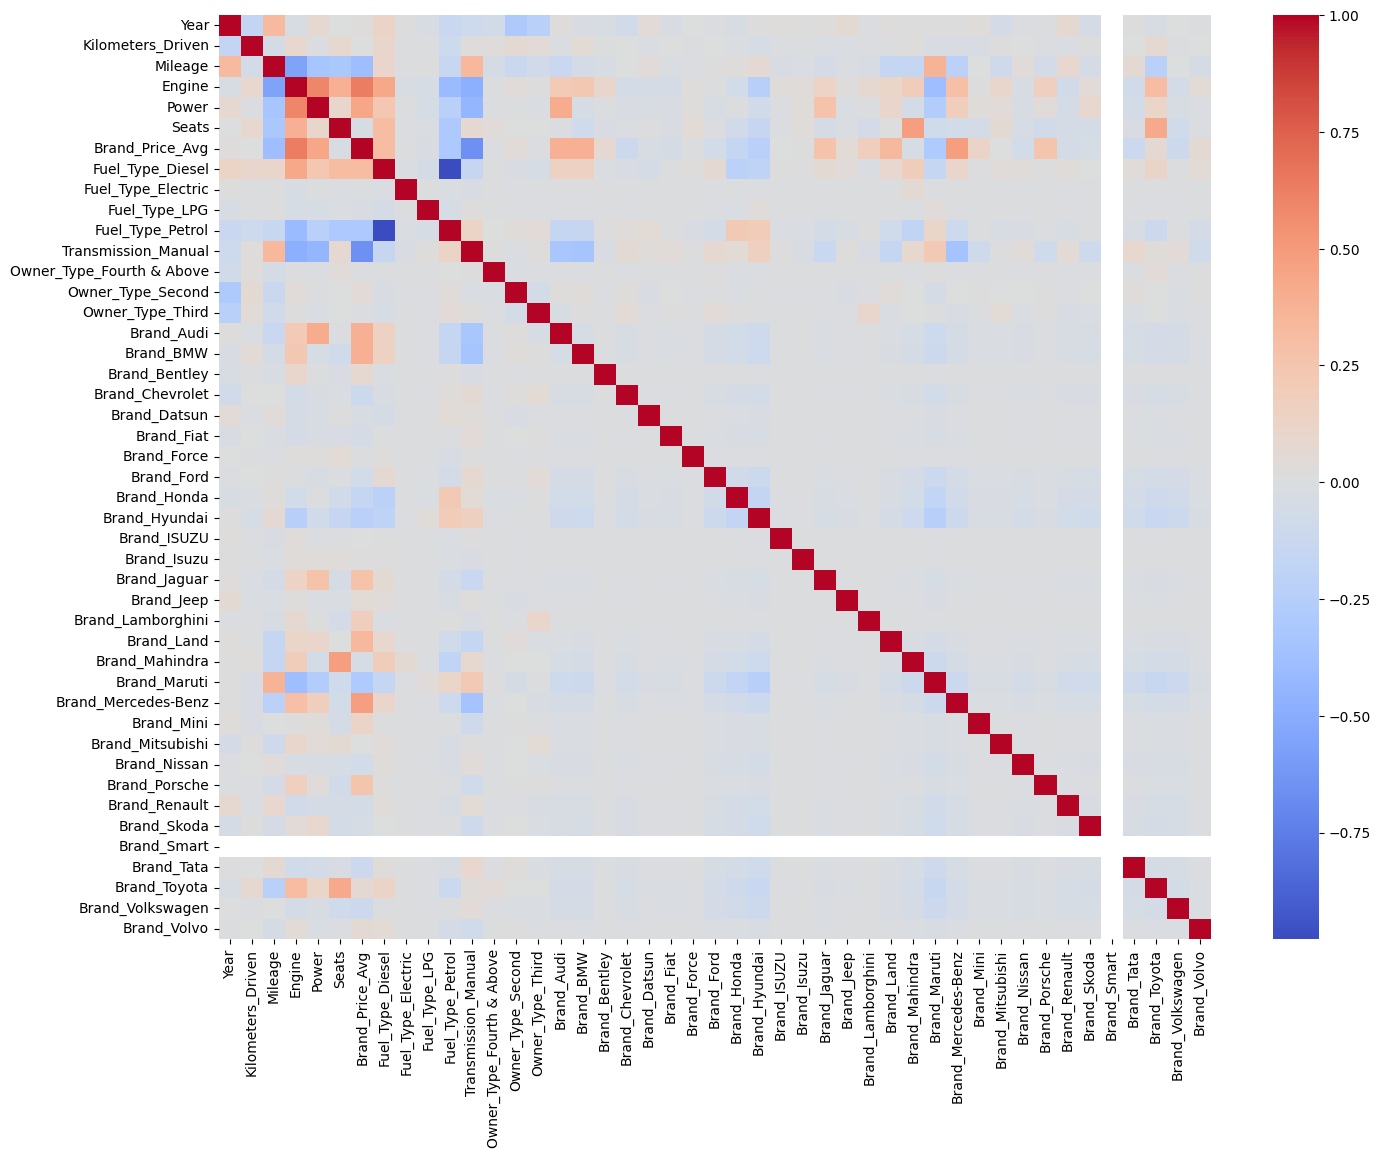

In [183]:
#Finding the correlation matrix for train dataset:
correlation = X_train_final.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation,
    xticklabels=correlation.columns,
    yticklabels=correlation.columns,
    cmap='coolwarm',
    annot=False
)

<Axes: >

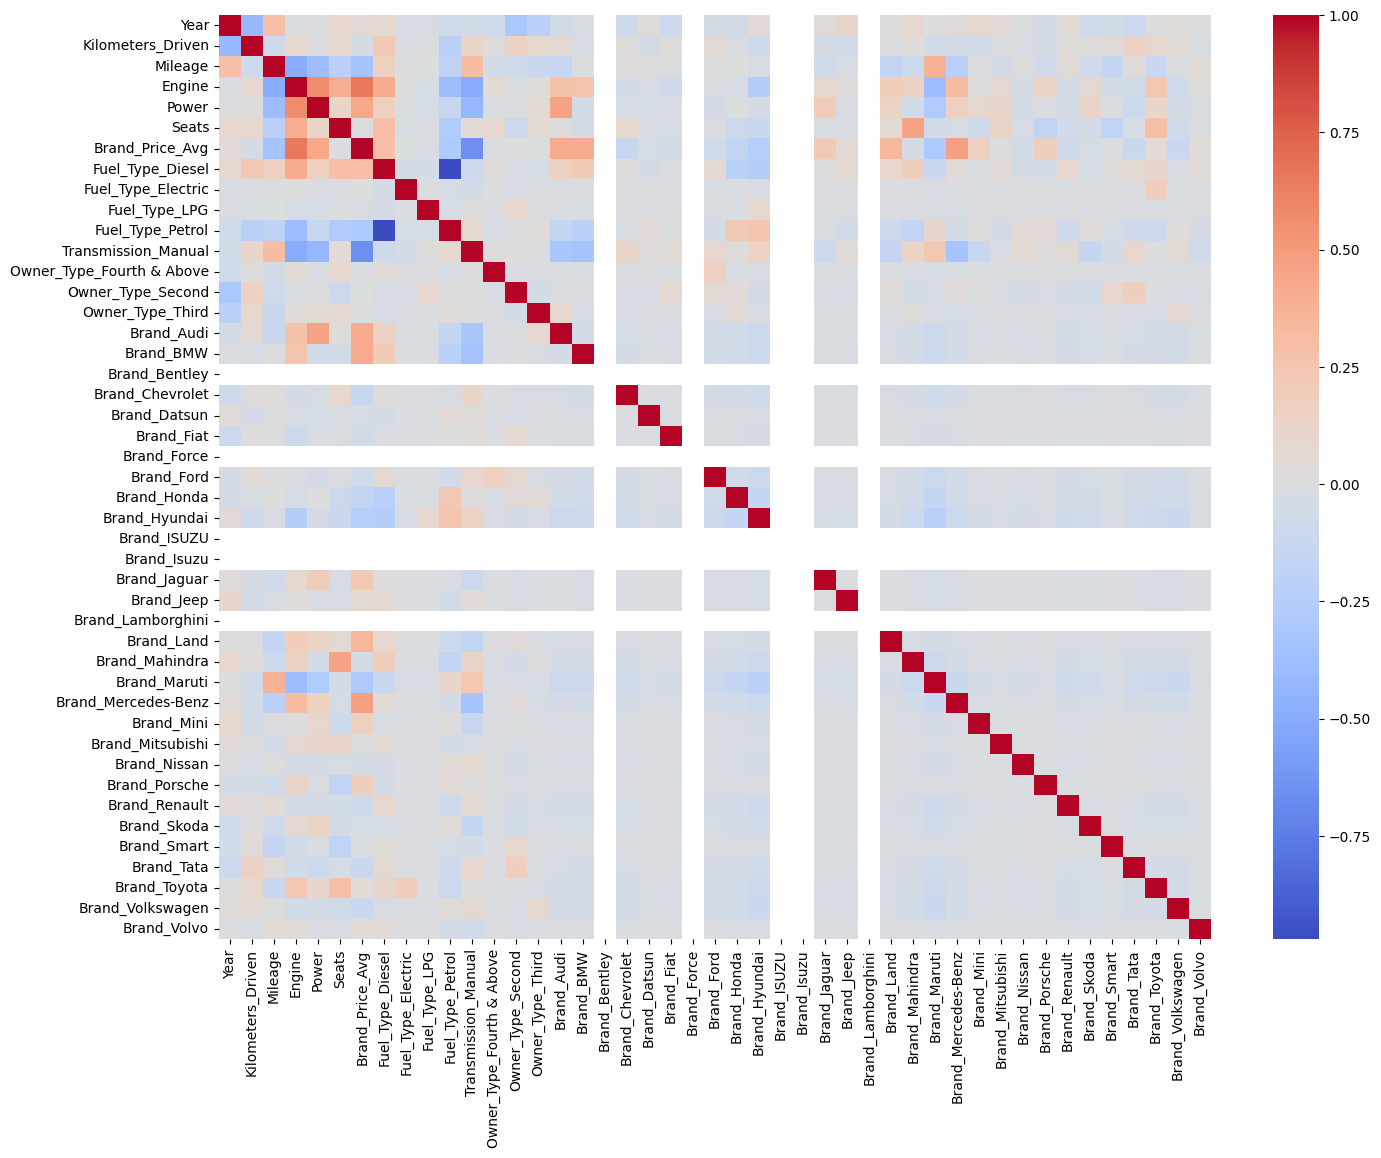

In [184]:
#Finding the correlation matrix for test dataset:
correlation = X_test_final.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation,
    xticklabels=correlation.columns,
    yticklabels=correlation.columns,
    cmap='coolwarm',
    annot=False
)

C:\Users\vedan\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


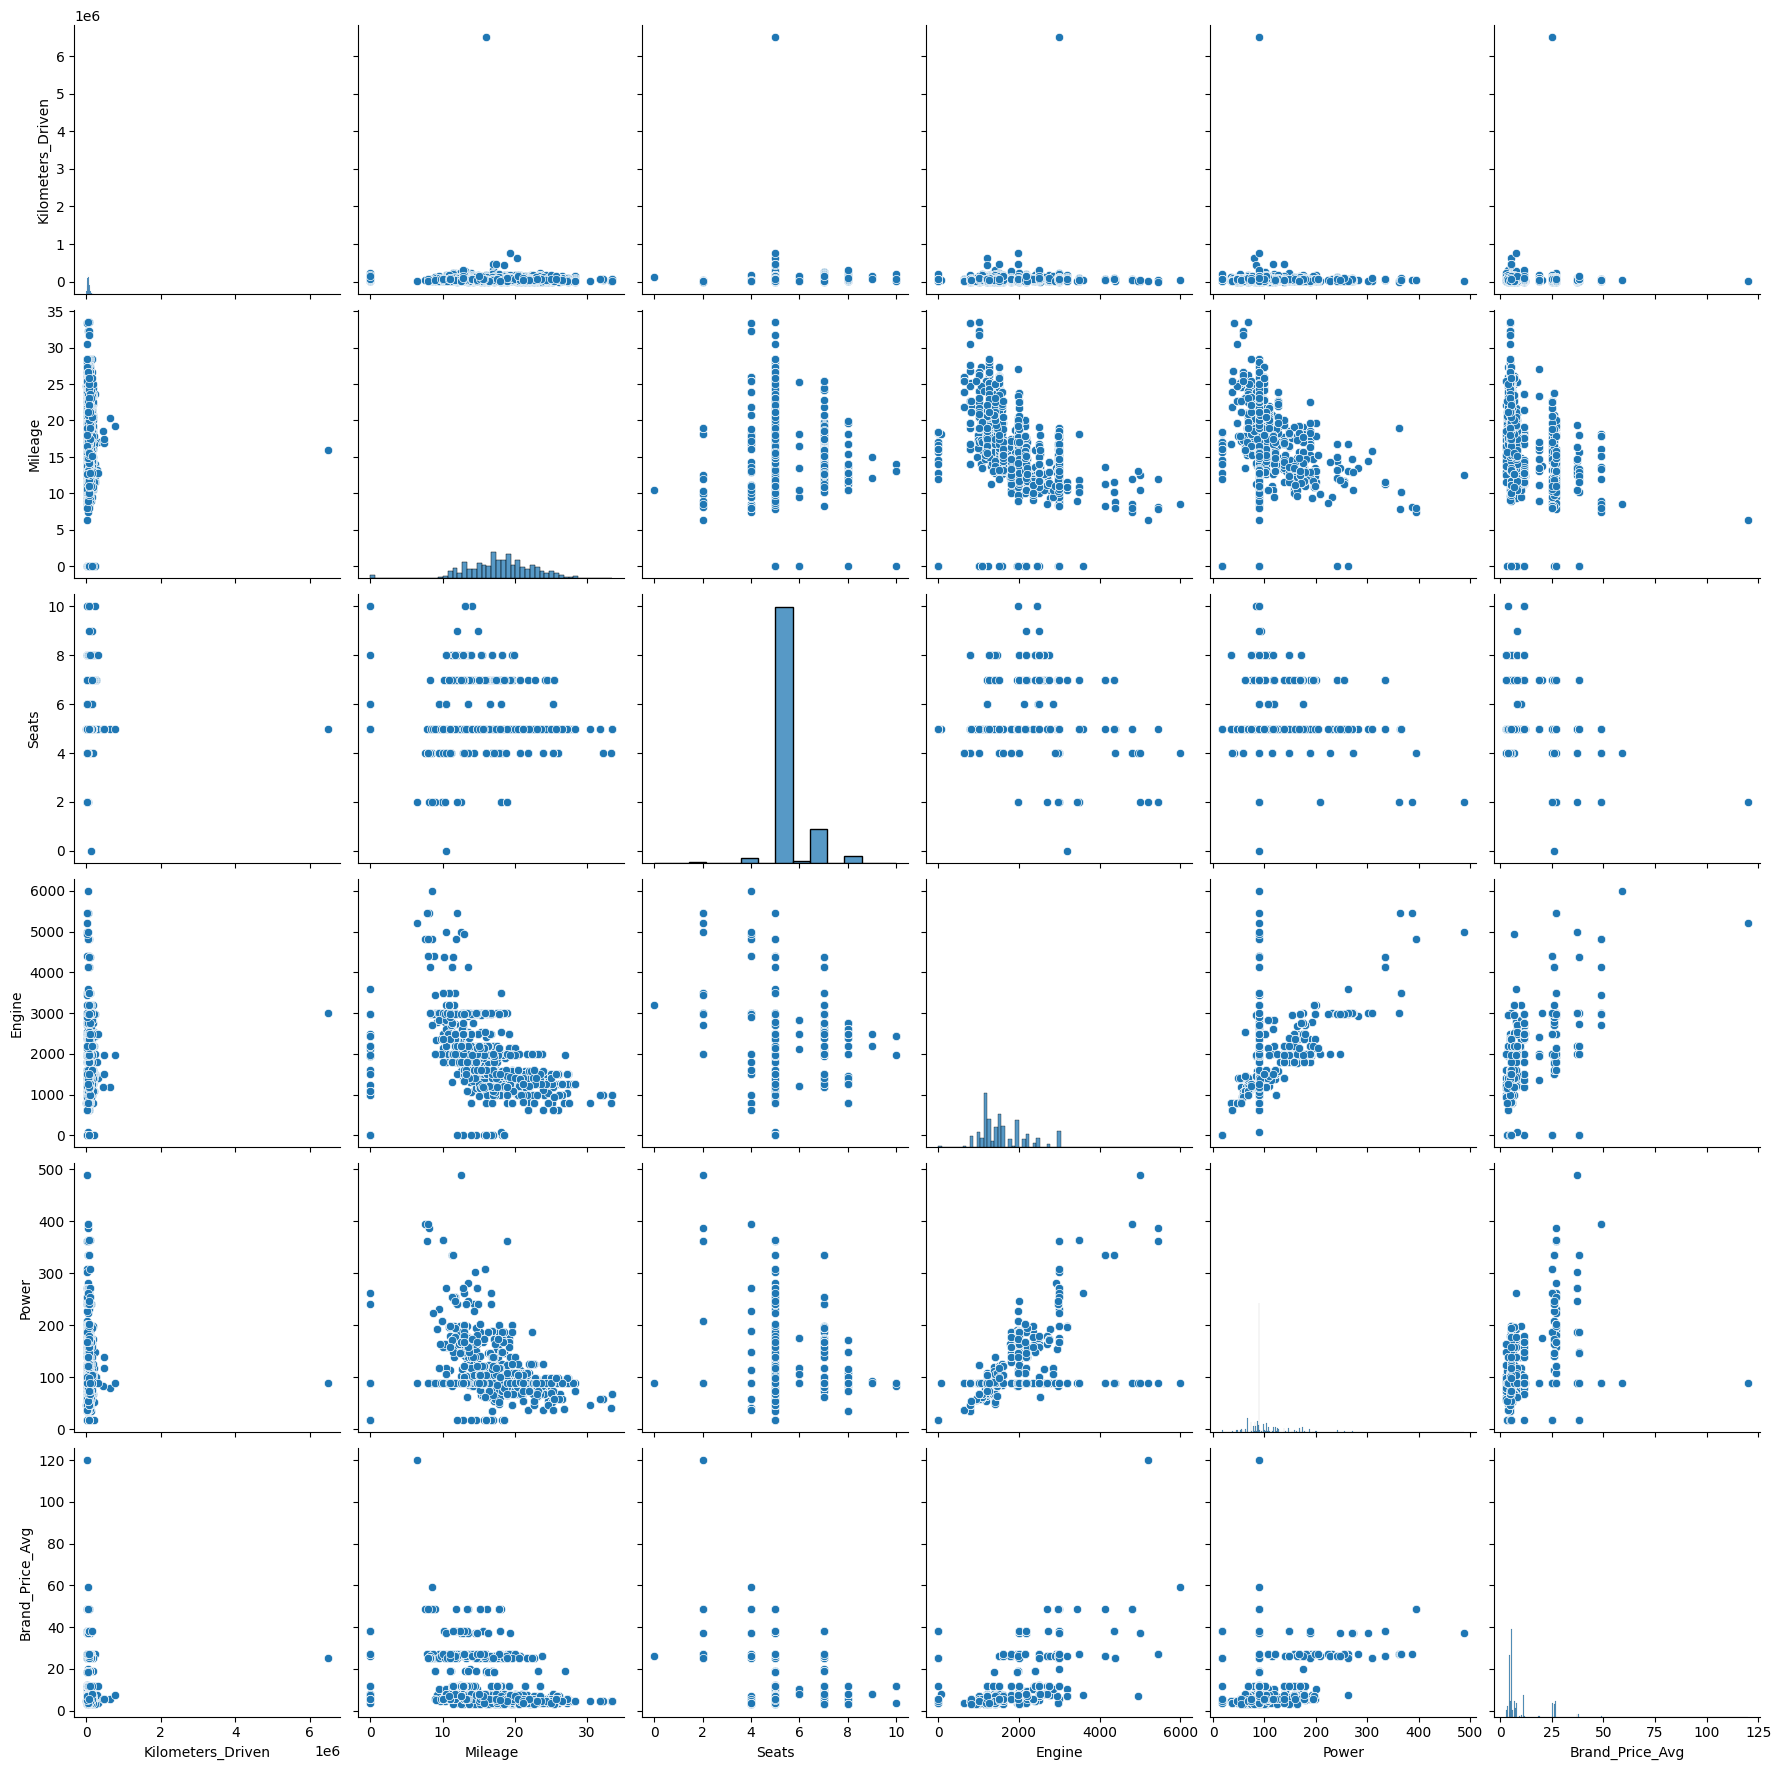

In [185]:
#scatter plot for numerical features
num_features = ["Kilometers_Driven","Mileage","Seats","Engine","Power","Brand_Price_Avg"]
sns.pairplot(X_train_final[num_features],size = 3.0)
plt.show();

C:\Users\vedan\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


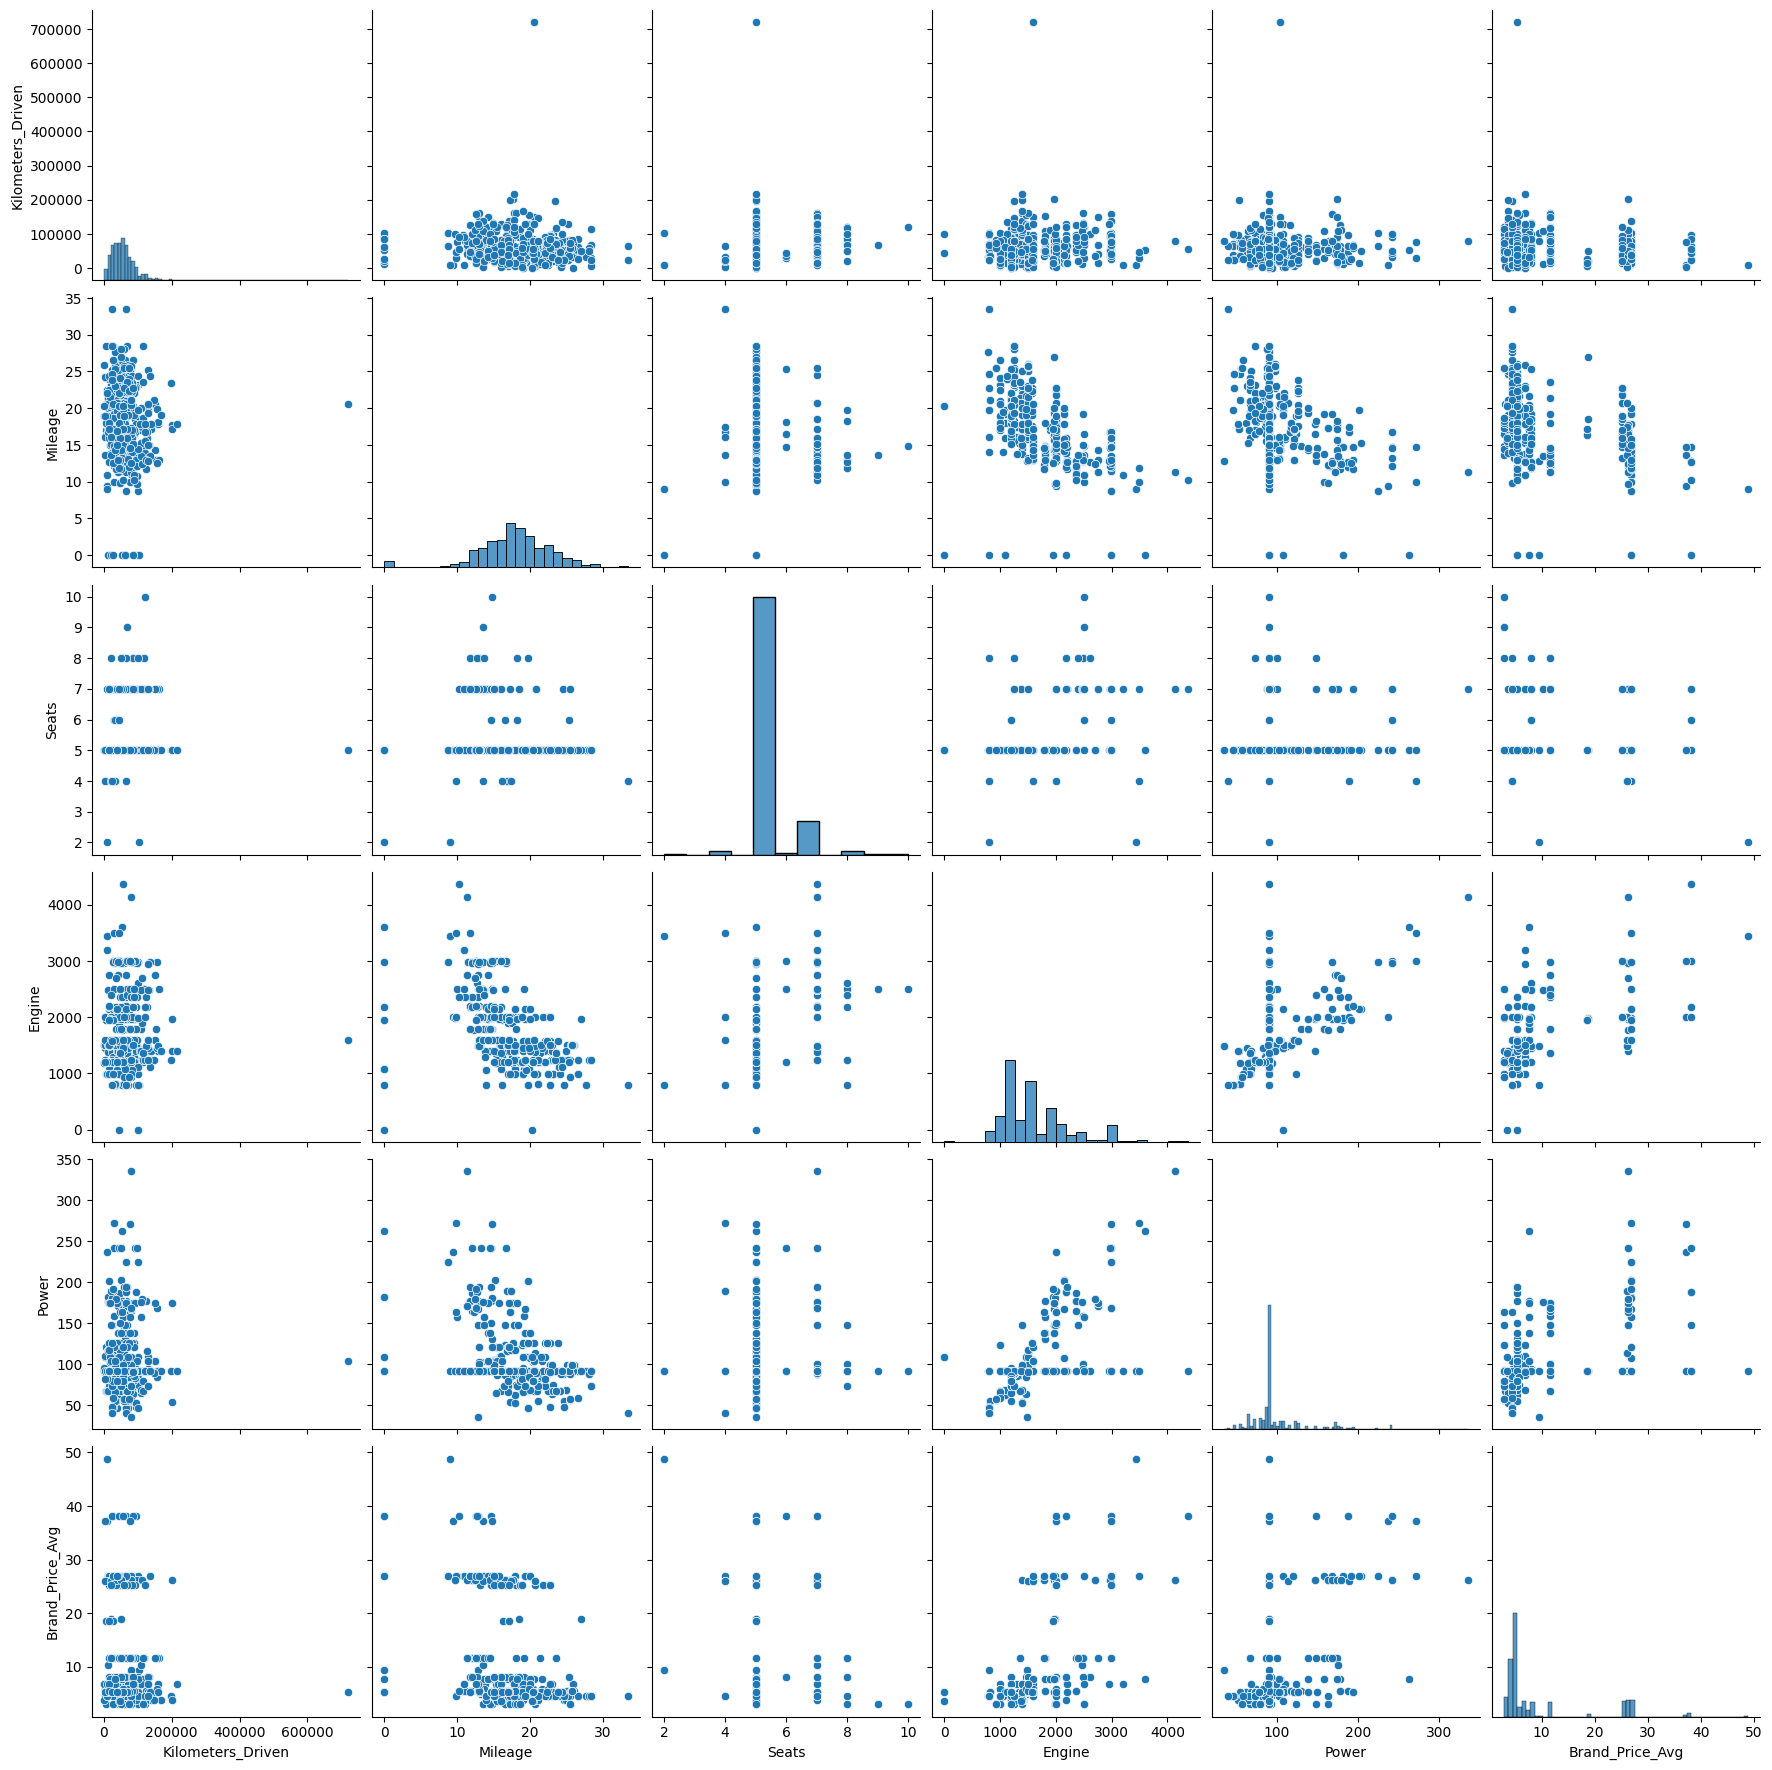

In [186]:
#scatter plot for numerical features
num_features = ["Kilometers_Driven","Mileage","Seats","Engine","Power","Brand_Price_Avg"]
sns.pairplot(X_test_final[num_features],size = 3.0)
plt.show();

C:\Users\vedan\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


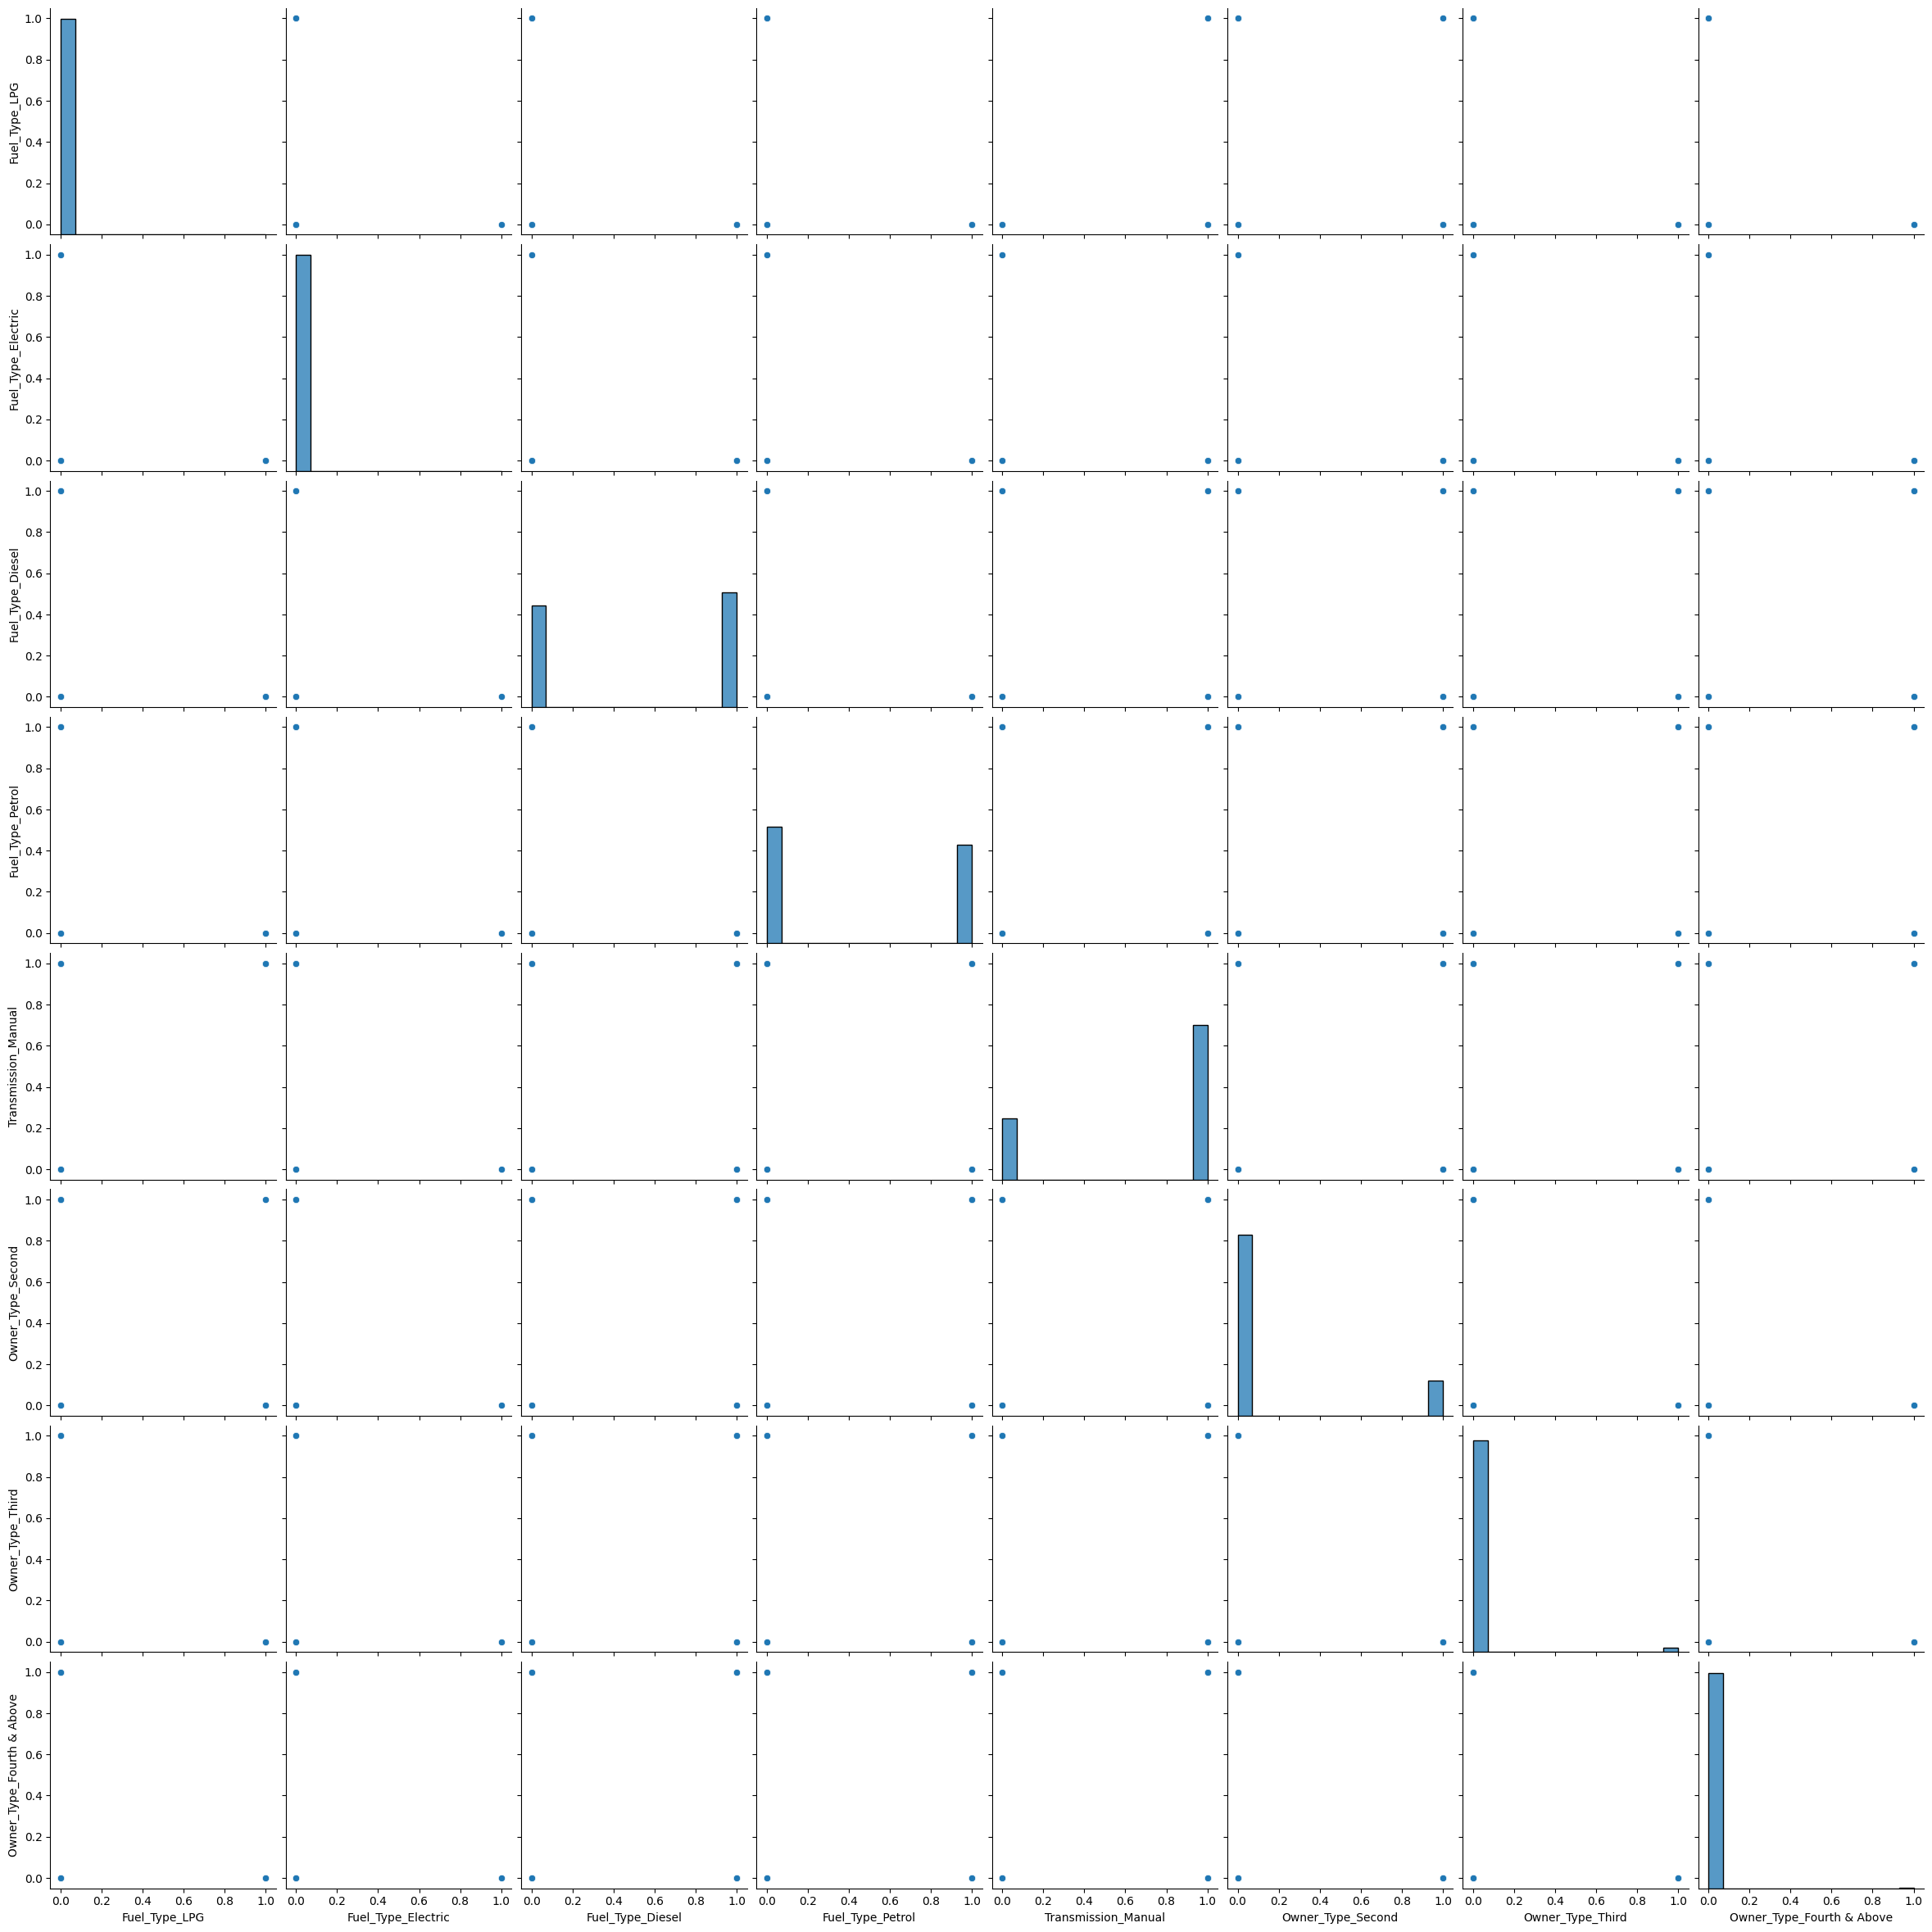

In [187]:
#scatter plot for categorical features:
num_features = ['Fuel_Type_LPG','Fuel_Type_Electric','Fuel_Type_Diesel','Fuel_Type_Petrol','Transmission_Manual', 'Owner_Type_Second','Owner_Type_Third','Owner_Type_Fourth & Above']
sns.pairplot(X_train_final[num_features],size = 3.0)
plt.show();

C:\Users\vedan\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


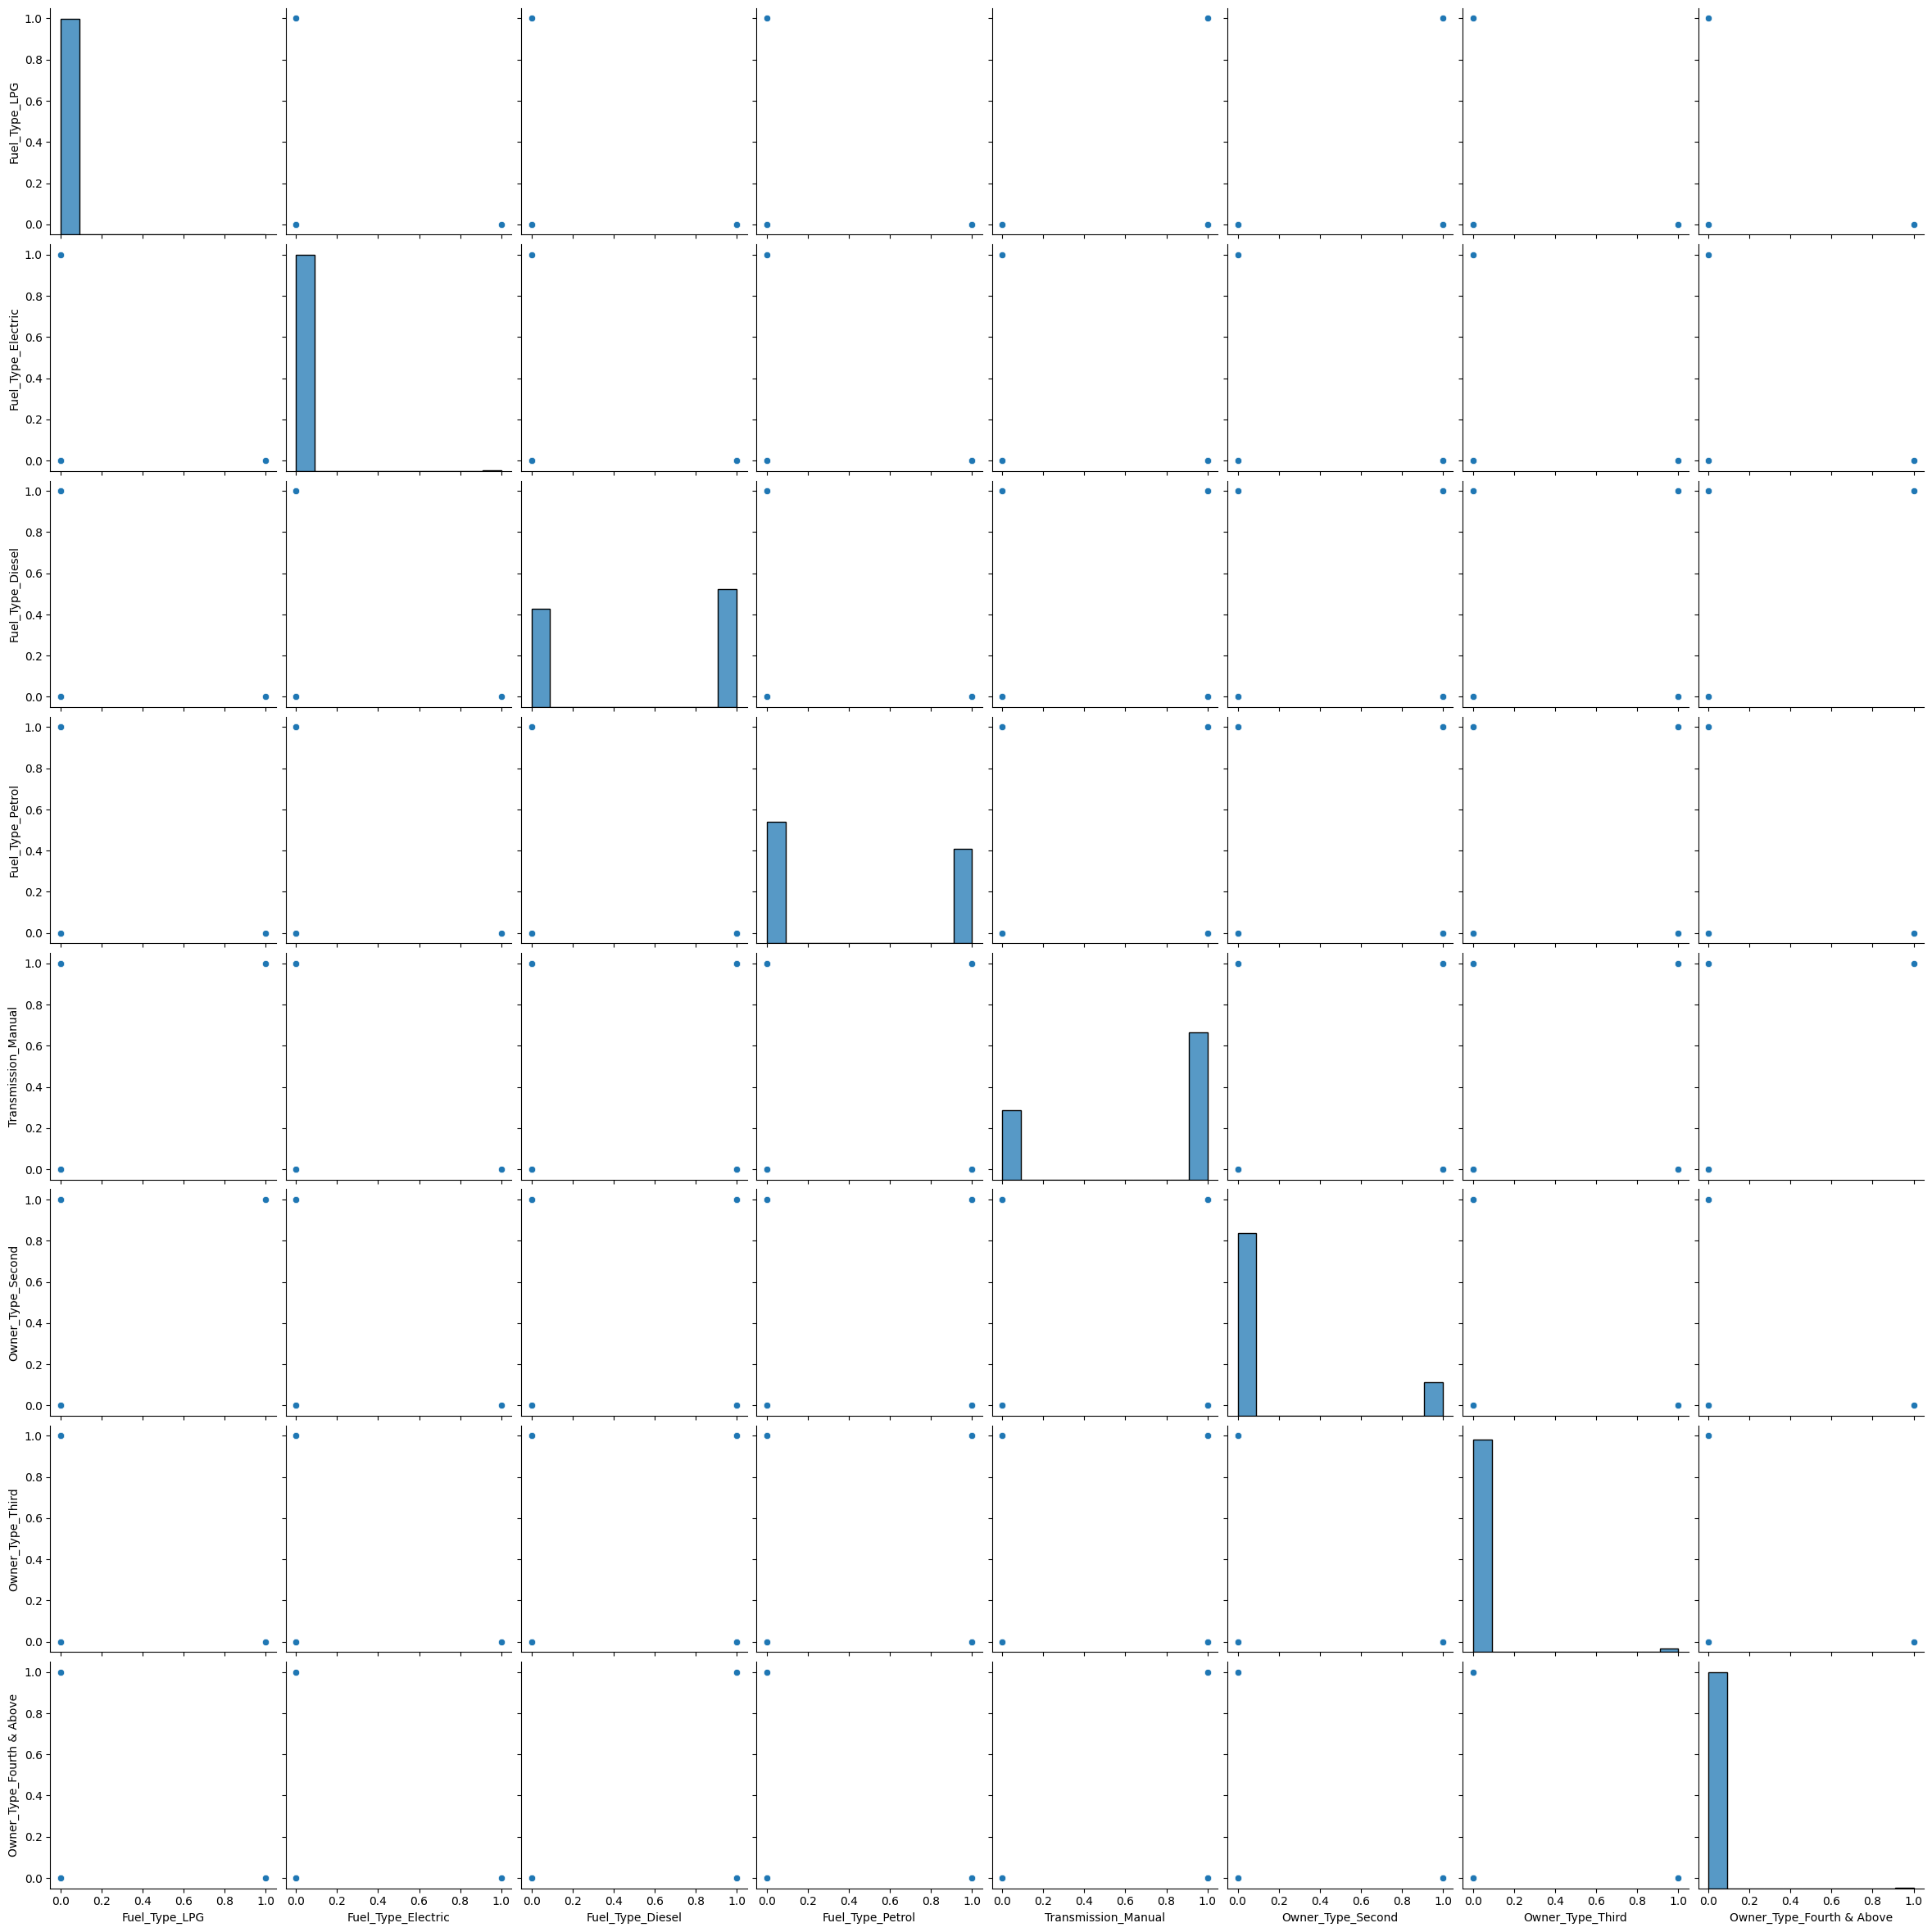

In [188]:
#scatter plot for categorical features:
num_features = ['Fuel_Type_LPG','Fuel_Type_Electric','Fuel_Type_Diesel','Fuel_Type_Petrol','Transmission_Manual','Owner_Type_Second','Owner_Type_Third','Owner_Type_Fourth & Above']
sns.pairplot(X_test_final[num_features],size = 3.0)
plt.show();

# Linear Regression

In [286]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X = X_train_final

y = train_labels

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

model = LinearRegression()
param_grid = {
    'fit_intercept': [True, False]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_split, y_train_split)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_model = grid_search.best_estimator_

val_predictions = best_model.predict(X_val)

print("\n--- Model Evaluation (on Validation Set) ---")

mse = mean_squared_error(y_val, val_predictions)
print(f"Mean Squared Error (MSE) with Best Model: {mse:.4f}")

rmse = mse ** 0.5
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

r2 = r2_score(y_val, val_predictions)
print(f"R-squared (R2) score: {r2:.4f}")

mae = mean_absolute_error(y_val, val_predictions)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Best Parameters: {'fit_intercept': True}

--- Model Evaluation (on Validation Set) ---
Mean Squared Error (MSE) with Best Model: 28.0482
Root Mean Squared Error (RMSE): 5.2961
R-squared (R2) score: 0.7430
Mean Absolute Error (MAE): 3.0432


# Random Forest Regressor

In [287]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV # Ensure GridSearchCV is imported
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X = X_train_final

y = train_labels

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rfr_model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 20],   
    'max_features': ['sqrt', 'log2', 0.8] 
}

grid_search = GridSearchCV(rfr_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_split, y_train_split)

best_params = grid_search.best_params_
print("\nBest Parameters:", best_params)

best_model = grid_search.best_estimator_

y_pred_val = best_model.predict(X_val)

print("\n--- Model Evaluation (on Unseen Validation Set) ---")

mse = mean_squared_error(y_val, y_pred_val)
print(f"Mean Squared Error (MSE) with Best Model: {mse:.4f}")

rmse = mse ** 0.5
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

r2 = r2_score(y_val, y_pred_val)
# If this R2 is close to 1, your model generalizes well.
print(f"R-squared (R2) score on the validation set: {r2:.4f}")

mae = mean_absolute_error(y_val, y_pred_val)
print(f"Mean Absolute Error (MAE): {mae:.4f}")


Best Parameters: {'max_depth': 20, 'max_features': 0.8, 'n_estimators': 200}

--- Model Evaluation (on Unseen Validation Set) ---
Mean Squared Error (MSE) with Best Model: 8.5243
Root Mean Squared Error (RMSE): 2.9196
R-squared (R2) score on the validation set: 0.9219
Mean Absolute Error (MAE): 1.3454


# Decision Tree Regressor

In [288]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X = X_train_final

y = train_labels

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

dt_model = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [2, 8, 9, 12], 
    'min_samples_split': [5, 10, 15]
}

grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_split, y_train_split)
print("Grid Search complete.")

best_params = grid_search.best_params_
print("\nBest Parameters:", best_params)

best_model = grid_search.best_estimator_

y_pred_val = best_model.predict(X_val)

print("\n--- Model Evaluation (Decision Tree on Validation Set) ---")

mse = mean_squared_error(y_val, y_pred_val)
print(f"Mean Squared Error (MSE) with Best Model: {mse:.4f}")

rmse = mse ** 0.5
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

r2 = r2_score(y_val, y_pred_val)

print(f"R-squared (R2) score on the validation set: {r2:.4f}")

mae = mean_absolute_error(y_val, y_pred_val)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Grid Search complete.

Best Parameters: {'max_depth': 9, 'min_samples_split': 15}

--- Model Evaluation (Decision Tree on Validation Set) ---
Mean Squared Error (MSE) with Best Model: 19.8578
Root Mean Squared Error (RMSE): 4.4562
R-squared (R2) score on the validation set: 0.8181
Mean Absolute Error (MAE): 1.8528


# K Nearest Neighbor

In [289]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor # <-- New Model
from sklearn.preprocessing import StandardScaler # <-- New Import for Scaling
from sklearn.pipeline import Pipeline # <-- New Import for Combining Steps
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X = X_train_final

y = train_labels

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_jobs=-1)) 
])

param_grid = {
    'knn__n_neighbors': [5, 10, 15, 20],
    'knn__weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train_split, y_train_split)
print("Grid Search complete.")

best_params = grid_search.best_params_
print("\nBest Parameters:", best_params)

best_model = grid_search.best_estimator_

# Predict on the held-out validation set (X_val)
y_pred_val = best_model.predict(X_val)

print("\n--- Model Evaluation (KNN Regressor on Validation Set) ---")

# Calculate evaluation metrics
mse = mean_squared_error(y_val, y_pred_val)
print(f"Mean Squared Error (MSE) with Best Model: {mse:.4f}")

rmse = mse ** 0.5
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

r2 = r2_score(y_val, y_pred_val)
print(f"R-squared (R2) score on the validation set: {r2:.4f}")

mae = mean_absolute_error(y_val, y_pred_val)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Grid Search complete.

Best Parameters: {'knn__n_neighbors': 5, 'knn__weights': 'distance'}

--- Model Evaluation (KNN Regressor on Validation Set) ---
Mean Squared Error (MSE) with Best Model: 10.2667
Root Mean Squared Error (RMSE): 3.2042
R-squared (R2) score on the validation set: 0.9059
Mean Absolute Error (MAE): 1.5153


# Support Vector Regressor

In [290]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X = X_train_final

y = train_labels
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())               
])

param_grid = {
    'svr__C': [1, 10],            
    'svr__gamma': ['scale'],      
    'svr__kernel': ['rbf']

}

grid_search = GridSearchCV(
    svr_pipeline,  
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train_split, y_train_split)
print("Grid Search complete.")

best_params = grid_search.best_params_
print("\nBest Parameters:", best_params)

best_model = grid_search.best_estimator_

y_pred_val = best_model.predict(X_val)

print("\n--- Model Evaluation (SVR on Validation Set) ---")

mse = mean_squared_error(y_val, y_pred_val)
print(f"Mean Squared Error (MSE) with Best Model: {mse:.4f}")

rmse = mse ** 0.5
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

r2 = r2_score(y_val, y_pred_val)
print(f"R-squared (R2) score on the validation set: {r2:.4f}")

mae = mean_absolute_error(y_val, y_pred_val)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Grid Search complete.

Best Parameters: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}

--- Model Evaluation (SVR on Validation Set) ---
Mean Squared Error (MSE) with Best Model: 16.7999
Root Mean Squared Error (RMSE): 4.0988
R-squared (R2) score on the validation set: 0.8461
Mean Absolute Error (MAE): 1.6968


# RESULTS

On comparing the Root Mean Square Error, Mean Absolute Error, Mean Square Error and R2 of all the above models we got the Random Forest Regressor model as a best model.

In [291]:
rfr_model.fit(X,y)

RandomForestRegressor(random_state=42)

In [292]:
rfr_model.score(X,y)

0.9838380854037139

In [293]:
y_pred_km_test = rfr_model.predict(X_test_final)

In [294]:
for price in y_pred_km_test:
    print(price)

4.0211
12.821700000000003
8.266599999999999
2.6792
1.698999999999999
3.7555000000000054
5.556550000000002
3.8710000000000004
9.5184
4.391499999999998
18.51889999999999
3.4261000000000013
2.251100000000002
18.50389999999999
3.999160000000001
3.2038999999999986
2.5011999999999985
6.343100000000001
26.126200000000004
5.889699999999997
8.521700000000001
7.808499999999999
4.934399999999996
9.238700000000009
5.2028
48.38879999999999
9.852200000000003
12.158999999999994
21.586499999999997
4.649399999999997
33.34519999999999
1.8763000000000003
1.86
2.6689999999999987
25.8191
8.995524999999997
38.46879999999999
4.5669
17.313600000000005
3.040000000000001
5.950200000000003
7.100199999999992
6.073199999999999
6.06170000000001
29.58670000000003
14.484299999999996
7.622100000000002
27.449999999999996
15.917900000000001
6.138547619047619
3.6860000000000017
4.2329
3.882299999999997
11.121896428571429
1.9183999999999997
10.714500000000003
17.908900000000003
6.8004
49.64219999999998
11.953500000000005


In [295]:
y_pred_km_test

array([  4.0211    ,  12.8217    ,   8.2666    ,   2.6792    ,
         1.699     ,   3.7555    ,   5.55655   ,   3.871     ,
         9.5184    ,   4.3915    ,  18.5189    ,   3.4261    ,
         2.2511    ,  18.5039    ,   3.99916   ,   3.2039    ,
         2.5012    ,   6.3431    ,  26.1262    ,   5.8897    ,
         8.5217    ,   7.8085    ,   4.9344    ,   9.2387    ,
         5.2028    ,  48.3888    ,   9.8522    ,  12.159     ,
        21.5865    ,   4.6494    ,  33.3452    ,   1.8763    ,
         1.86      ,   2.669     ,  25.8191    ,   8.995525  ,
        38.4688    ,   4.5669    ,  17.3136    ,   3.04      ,
         5.9502    ,   7.1002    ,   6.0732    ,   6.0617    ,
        29.5867    ,  14.4843    ,   7.6221    ,  27.45      ,
        15.9179    ,   6.13854762,   3.686     ,   4.2329    ,
         3.8823    ,  11.12189643,   1.9184    ,  10.7145    ,
        17.9089    ,   6.8004    ,  49.6422    ,  11.9535    ,
         1.159     ,   3.2606    ,   1.1347    ,  41.66

In [296]:
y_pred_km_test_2 = np.round(y_pred_km_test,2)

In [297]:
y_pred_km_test_2

array([  4.02,  12.82,   8.27,   2.68,   1.7 ,   3.76,   5.56,   3.87,
         9.52,   4.39,  18.52,   3.43,   2.25,  18.5 ,   4.  ,   3.2 ,
         2.5 ,   6.34,  26.13,   5.89,   8.52,   7.81,   4.93,   9.24,
         5.2 ,  48.39,   9.85,  12.16,  21.59,   4.65,  33.35,   1.88,
         1.86,   2.67,  25.82,   9.  ,  38.47,   4.57,  17.31,   3.04,
         5.95,   7.1 ,   6.07,   6.06,  29.59,  14.48,   7.62,  27.45,
        15.92,   6.14,   3.69,   4.23,   3.88,  11.12,   1.92,  10.71,
        17.91,   6.8 ,  49.64,  11.95,   1.16,   3.26,   1.13,  41.67,
         5.8 ,   8.84,   3.82,  11.57,  36.72,   1.6 ,  12.17,   5.86,
         1.45,  20.98,   5.16,   5.55,  25.28,   5.43,   4.74,   3.97,
         4.61,   4.72,   5.31,   4.85,   4.71,  27.16,  50.17,  13.56,
         5.43,  15.22,   3.25,   5.7 ,  23.03,   6.77,   3.26,   2.91,
         4.28,   4.92,   5.12,   1.44,   5.86,   2.95,  12.95,   6.07,
         4.82,   5.17,   3.93,   6.01,   1.78,   4.09,   3.41,   7.56,
      

In [298]:
results_df = test_data.copy()

In [299]:
results_df['Predicted_Price_Lakhs'] = y_pred_km_test_2

In [300]:
results_df

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Brand_Price_Avg,Predicted_Price_Lakhs
0,Hyderabad,2013,69000,Diesel,Manual,First,23.4 kmpl,1248 CC,74 bhp,5.0,Maruti,4.523382,4.02
1,Kochi,2017,26741,Diesel,Manual,First,15.4 kmpl,1997 CC,120 bhp,7.0,Mahindra,8.003264,12.82
2,Delhi,2014,86000,Diesel,Manual,First,15.1 kmpl,2179 CC,140 bhp,7.0,Mahindra,8.003264,8.27
3,Pune,2016,52000,Diesel,Manual,Second,25.0 kmpl,1396 CC,69.01 bhp,5.0,Tata,3.673550,2.68
4,Pune,2009,100000,Petrol,Manual,First,0.0 kmpl,0 NaN\ndtype: float64 cc,0 108.355665\ndtype: float64 bhp,5.0,Hyundai,5.334673,1.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,Mumbai,2008,78000,Petrol,Automatic,Second,14.53 kmpl,1794 CC,138.1 bhp,5.0,Toyota,11.532730,3.10
598,Chennai,2012,55231,Petrol,Manual,Second,20.36 kmpl,1197 CC,78.9 bhp,5.0,Hyundai,5.334673,3.26
599,Jaipur,2010,130000,Diesel,Manual,Second,19.3 kmpl,1248 CC,73.9 bhp,5.0,Maruti,4.523382,3.37
600,Ahmedabad,2016,39500,Diesel,Automatic,First,15.0 kmpl,2143 CC,204 bhp,5.0,Mercedes-Benz,26.870421,28.88


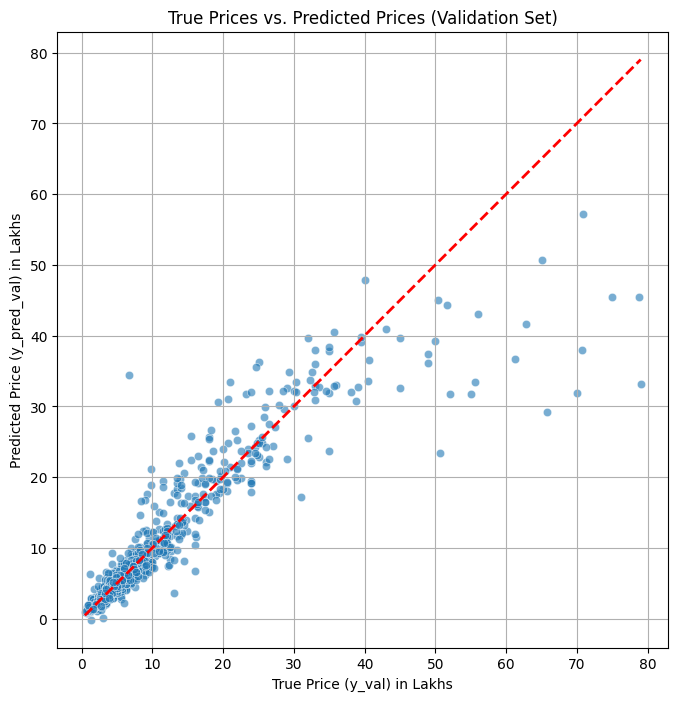

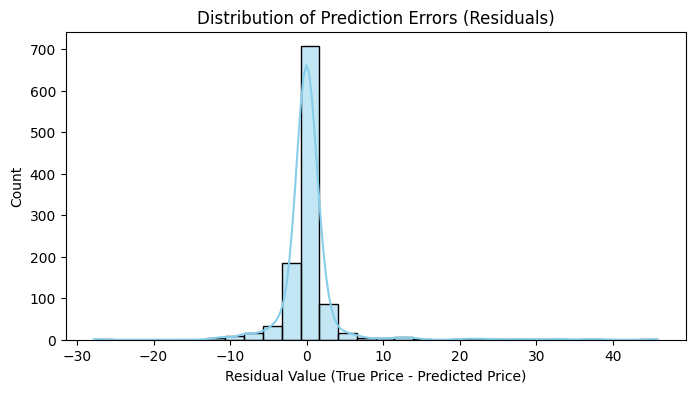

In [301]:
plt.figure(figsize=(8, 8))

sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.6)

plt.plot(
    [y_val.min(), y_val.max()], 
    [y_val.min(), y_val.max()], 
    color='red', 
    linestyle='--', 
    lw=2
)

plt.title('True Prices vs. Predicted Prices (Validation Set)')
plt.xlabel('True Price (y_val) in Lakhs')
plt.ylabel('Predicted Price (y_pred_val) in Lakhs')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') 
plt.show()

residuals = y_val - y_pred_val
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Residual Value (True Price - Predicted Price)')
plt.show()

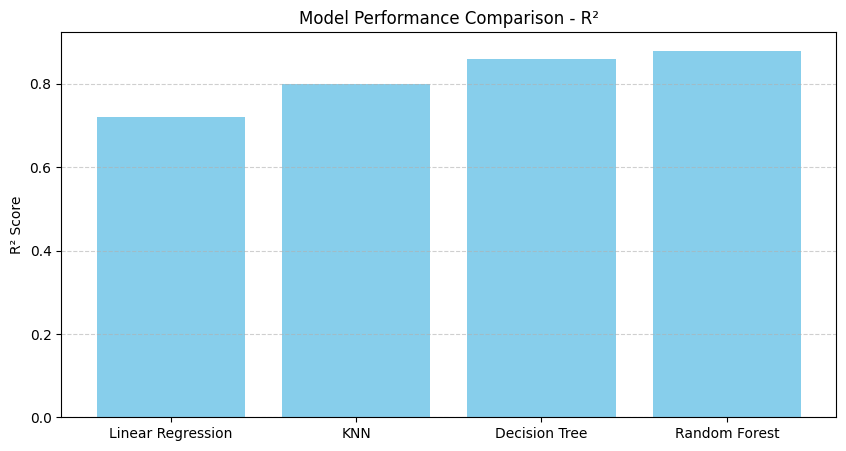

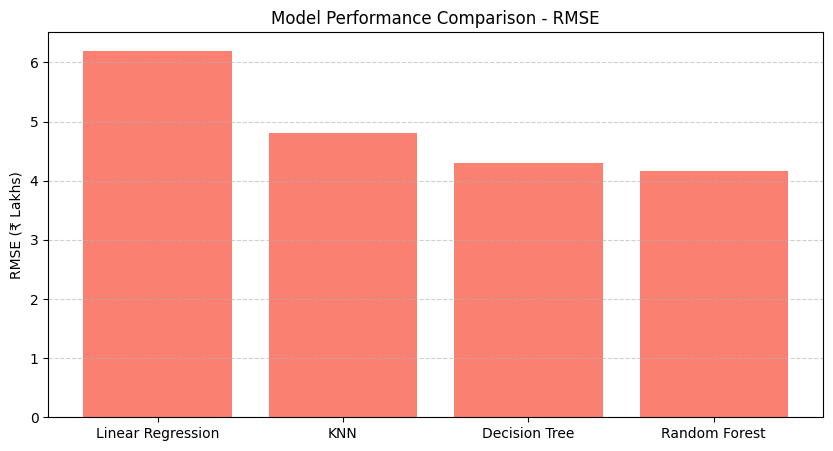

In [304]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest']
r2_scores = [0.72, 0.80, 0.86, 0.88]   # Example values — replace with your real ones
rmse_scores = [6.2, 4.8, 4.3, 4.16]    # Example values in Lakhs

# R² Plot
plt.figure(figsize=(10, 5))
plt.bar(models, r2_scores, color='skyblue')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison - R²')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# RMSE Plot
plt.figure(figsize=(10, 5))
plt.bar(models, rmse_scores, color='salmon')
plt.ylabel('RMSE (₹ Lakhs)')
plt.title('Model Performance Comparison - RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [302]:
import joblib
import os

model_filename = 'backend/final_best_model2.joblib'

joblib.dump(best_model, model_filename)

print(f"✅ Model successfully saved as: {model_filename}")
print(f"File size: {os.path.getsize(model_filename) / (1024*1024):.2f} MB")

✅ Model successfully saved as: backend/final_best_model2.joblib
File size: 1.46 MB


In [ ]:
Predictions For Different Cars

In [ ]:
import joblib
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

BRAND_AVG_PRICE_MAP = {
    'Maruti': 4.52, 'Audi': 26.19, 'Toyota': 11.53, 'BMW': 35.50,
    'Hyundai': 6.75, 'Honda': 7.48, 'Mahindra': 8.62, 'Tata': 6.12,
    'Mercedes-Benz': 40.15, 'Volkswagen': 10.28, 'Ford': 9.11,
}

OVERALL_AVG_PRICE = 9.45

MEDIAN_IMPUTATION_MAP = {
    'Power': 95.0,
    'Engine': 1498.0,
    'Mileage': 18.0,
    'Seats': 5.0
}

FINAL_FEATURE_COLUMNS = [
    'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
    'Brand_Price_Avg', 'Fuel_Type_Diesel', 'Fuel_Type_Electric',
    'Fuel_Type_LPG', 'Fuel_Type_Petrol', 'Transmission_Manual',
    'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third',
    'Brand_Audi', 'Brand_BMW', 'Brand_Bentley', 'Brand_Chevrolet',
    'Brand_Datsun', 'Brand_Fiat', 'Brand_Force', 'Brand_Ford',
    'Brand_Honda', 'Brand_Hyundai', 'Brand_ISUZU', 'Brand_Isuzu',
    'Brand_Jaguar', 'Brand_Jeep', 'Brand_Lamborghini', 'Brand_Land',
    'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes-Benz', 'Brand_Mini',
    'Brand_Mitsubishi', 'Brand_Nissan', 'Brand_Porsche', 'Brand_Renault',
    'Brand_Skoda', 'Brand_Smart', 'Brand_Tata', 'Brand_Toyota',
    'Brand_Volkswagen', 'Brand_Volvo'
]

CATEGORICAL_COLS = ['Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']

MODEL_PATH = "final_best_model2.joblib"


if not Path(MODEL_PATH).exists():
    raise FileNotFoundError(f" Model file not found: {MODEL_PATH}. Please upload it to the same folder.")

with open(MODEL_PATH, "rb") as f:
    best_model = joblib.load(f)
print("✅ Model successfully loaded!")

def predict_car_price(new_car_data: dict) -> float:
    
    df = pd.DataFrame([new_car_data])

    df['Manufacturer'] = df['Brand'].str.split(' ').str[0]
    df.drop(columns=['Brand'], inplace=True)
    df.rename(columns={'Manufacturer': 'Brand'}, inplace=True)

    df['Brand_Price_Avg'] = df['Brand'].map(BRAND_AVG_PRICE_MAP).fillna(OVERALL_AVG_PRICE)

    for col, median_val in MEDIAN_IMPUTATION_MAP.items():
        if col in df.columns:
            df[col] = df[col].fillna(median_val)

    df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS, drop_first=True)

    df_encoded = df_encoded.drop(columns=['Year', 'Location'], errors='ignore')

    X_predict = df_encoded.reindex(columns=FINAL_FEATURE_COLUMNS, fill_value=0)

    prediction = best_model.predict(X_predict)
    return round(float(prediction[0]), 2)

new_car = {
    'Brand': 'Audi',
    'Location': 'Delhi',
    'Year': 2021,
    'Kilometers_Driven': 15000,
    'Fuel_Type': 'Diesel',
    'Transmission': 'Automatic',
    'Owner_Type': 'First',
    'Mileage': 14.5,
    'Engine': 1968.0,
    'Power': 190.0,
    'Seats': 5.0
}

In [221]:
print(f"{predict_car_price(new_car)} Lakhs")

23.04 Lakhs


In [222]:
sample_cars = [
    {
        'Brand': 'Maruti Swift',
        'Location': 'Mumbai',
        'Year': 2018,
        'Kilometers_Driven': 42000,
        'Fuel_Type': 'Petrol',
        'Transmission': 'Manual',
        'Owner_Type': 'First',
        'Mileage': 20.4,
        'Engine': 1197.0,
        'Power': 83.0,
        'Seats': 5.0
    },
    {
        'Brand': 'Hyundai Creta',
        'Location': 'Bangalore',
        'Year': 2020,
        'Kilometers_Driven': 25000,
        'Fuel_Type': 'Diesel',
        'Transmission': 'Automatic',
        'Owner_Type': 'First',
        'Mileage': 19.7,
        'Engine': 1493.0,
        'Power': 115.0,
        'Seats': 5.0
    },
    {
        'Brand': 'Honda City',
        'Location': 'Delhi',
        'Year': 2017,
        'Kilometers_Driven': 58000,
        'Fuel_Type': 'Petrol',
        'Transmission': 'Manual',
        'Owner_Type': 'Second',
        'Mileage': 17.4,
        'Engine': 1497.0,
        'Power': 119.0,
        'Seats': 5.0
    },
    {
        'Brand': 'Toyota Fortuner',
        'Location': 'Chennai',
        'Year': 2019,
        'Kilometers_Driven': 30000,
        'Fuel_Type': 'Diesel',
        'Transmission': 'Automatic',
        'Owner_Type': 'First',
        'Mileage': 14.2,
        'Engine': 2755.0,
        'Power': 174.0,
        'Seats': 7.0
    },
    {
        'Brand': 'BMW X1',
        'Location': 'Pune',
        'Year': 2021,
        'Kilometers_Driven': 12000,
        'Fuel_Type': 'Diesel',
        'Transmission': 'Automatic',
        'Owner_Type': 'First',
        'Mileage': 19.6,
        'Engine': 1995.0,
        'Power': 188.0,
        'Seats': 5.0
    },
    {
        'Brand': 'Tata Nexon',
        'Location': 'Hyderabad',
        'Year': 2022,
        'Kilometers_Driven': 10000,
        'Fuel_Type': 'Petrol',
        'Transmission': 'Manual',
        'Owner_Type': 'First',
        'Mileage': 17.0,
        'Engine': 1199.0,
        'Power': 118.0,
        'Seats': 5.0
    },
    {
        'Brand': 'Mahindra XUV500',
        'Location': 'Jaipur',
        'Year': 2018,
        'Kilometers_Driven': 55000,
        'Fuel_Type': 'Diesel',
        'Transmission': 'Manual',
        'Owner_Type': 'Second',
        'Mileage': 15.1,
        'Engine': 2179.0,
        'Power': 140.0,
        'Seats': 7.0
    },
    {
        'Brand': 'Ford EcoSport',
        'Location': 'Delhi',
        'Year': 2019,
        'Kilometers_Driven': 38000,
        'Fuel_Type': 'Petrol',
        'Transmission': 'Automatic',
        'Owner_Type': 'First',
        'Mileage': 15.8,
        'Engine': 1497.0,
        'Power': 121.0,
        'Seats': 5.0
    },
    {
        'Brand': 'Mercedes-Benz C-Class',
        'Location': 'Kolkata',
        'Year': 2021,
        'Kilometers_Driven': 18000,
        'Fuel_Type': 'Diesel',
        'Transmission': 'Automatic',
        'Owner_Type': 'First',
        'Mileage': 19.3,
        'Engine': 1950.0,
        'Power': 194.0,
        'Seats': 5.0
    },
    {
        'Brand': 'Volkswagen Polo',
        'Location': 'Ahmedabad',
        'Year': 2016,
        'Kilometers_Driven': 65000,
        'Fuel_Type': 'Petrol',
        'Transmission': 'Manual',
        'Owner_Type': 'Second',
        'Mileage': 17.2,
        'Engine': 1198.0,
        'Power': 74.0,
        'Seats': 5.0
    }
]

In [223]:
for i, car in enumerate(sample_cars, start=1):
    price = predict_car_price(car)
    print(f"{i}. {car['Brand']} ({car['Year']}): ₹{price:.2f} Lakhs")


1. Maruti Swift (2018): ₹3.98 Lakhs
2. Hyundai Creta (2020): ₹9.21 Lakhs
3. Honda City (2017): ₹6.87 Lakhs
4. Toyota Fortuner (2019): ₹24.07 Lakhs
5. BMW X1 (2021): ₹26.68 Lakhs
6. Tata Nexon (2022): ₹8.49 Lakhs
7. Mahindra XUV500 (2018): ₹15.91 Lakhs
8. Ford EcoSport (2019): ₹8.49 Lakhs
9. Mercedes-Benz C-Class (2021): ₹26.84 Lakhs
10. Volkswagen Polo (2016): ₹2.78 Lakhs
